In [1]:
import json
import os
import subprocess
import cv2
import decord
import plotly.express as px
import mediapy
import pickle
import tqdm

import sys
sys.path.insert(0, "..")

import numpy as np
import torch
import torch.nn.functional as F
VIDEO_PATH = "/home/ubuntu/inwdata/prithvi/alert_sync/nd-training-data-production/fe20bb86-bc39-4321-a42c-45c2278fced1/8.mp4"
IMG_SIZE = 384*2
IMAGENET_DEFAULT_MEAN = (0.485, 0.456, 0.406)
IMAGENET_DEFAULT_STD = (0.229, 0.224, 0.225)

In [2]:
# drowsy avids
# 1. 005a5914-4a94-45b3-b753-c9e994cc13d3
# 2. fe20bb86-bc39-4321-a42c-45c2278fced1

# cropping to 512

In [3]:
vr = mediapy.read_video(VIDEO_PATH)
print(vr.shape)

(1800, 1296, 1296, 3)


In [4]:
fps6 = vr[::3]
cropped_6fps = fps6[:, 528:(528+IMG_SIZE), 400:(400+IMG_SIZE)]
print(fps6.shape)
print(cropped_6fps.shape)

(600, 1296, 1296, 3)
(600, 768, 768, 3)


In [5]:
px.imshow(cropped_6fps[0])

In [6]:
# mediapy.show_video(cropped_6fps, fps=6)

# dummy

In [ ]:
pt = torch.load("../models/vjepa2_1_vitg_384.pt", weights_only=True, map_location="cpu")

In [ ]:
for k in pt.keys():
    print(k)

encoder
predictor
opt
scaler
target_encoder
epoch
loss
batch_size
world_size
lr


In [ ]:
pt['world_size']

512

In [ ]:
from src.models.vision_transformer import *
from fvcore.nn import parameter_count_table

In [ ]:
model = vit_large_rope()
print(parameter_count_table(model, max_depth=2))

| name             | #elements or shape   |
|:-----------------|:---------------------|
| model            | 0.3G                 |
| patch_embed      | 0.8M                 |
| patch_embed.proj | 0.8M                 |
| blocks           | 0.3G                 |
| blocks.0         | 12.6M                |
| blocks.1         | 12.6M                |
| blocks.2         | 12.6M                |
| blocks.3         | 12.6M                |
| blocks.4         | 12.6M                |
| blocks.5         | 12.6M                |
| blocks.6         | 12.6M                |
| blocks.7         | 12.6M                |
| blocks.8         | 12.6M                |
| blocks.9         | 12.6M                |
| blocks.10        | 12.6M                |
| blocks.11        | 12.6M                |
| blocks.12        | 12.6M                |
| blocks.13        | 12.6M                |
| blocks.14        | 12.6M                |
| blocks.15        | 12.6M                |
| blocks.16        | 12.6M      

In [ ]:
import sys
sys.path.insert(0, "..")
from src.models.vision_transformer import vit_giant_xformers_rope
from torchview import draw_graph

model_pt = vit_giant_xformers_rope(img_size=(384, 384), num_frames=360)
model_pt.cuda(1).eval()

model_graph = draw_graph(
    model_pt,
    input_size=(1, 3, 8, 64, 64),   # small input, shapes scale correctly
    device="cuda:1",
    depth=3,                          # nesting depth of modules shown
    expand_nested=True,               # unfold sub-modules like attention blocks
    graph_name="vit_giant",
    roll=True,                        # collapse repeated blocks (e.g. 40 ViT layers → 1 rolled)
)

model_graph.visual_graph.render("model_architecture", format="png", cleanup=True)
# also available as SVG for infinite zoom:
model_graph.visual_graph.render("model_architecture", format="svg", cleanup=True)

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.244568 to fit


dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.244568 to fit


'model_architecture.svg'

# inference

In [7]:
import sys
sys.path.insert(0, "..")
from src.models.vision_transformer import vit_giant_xformers_rope
import src.datasets.utils.video.transforms as video_transforms
import src.datasets.utils.video.volume_transforms as volume_transforms

/home/ubuntu/inwdata/prithvi/git/vjepa2/venv/lib/python3.13/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [8]:
def load_pretrained_vjepa_pt_weights(model, pretrained_weights):
    # Load weights of the VJEPA2 encoder
    # Load to CPU first to avoid GPU memory spikes, then load_state_dict
    # copies only the needed tensors to the model's device
    pretrained_dict = torch.load(pretrained_weights, weights_only=True, map_location="cpu")["encoder"]
    pretrained_dict = {k.replace("module.", ""): v for k, v in pretrained_dict.items()}
    pretrained_dict = {k.replace("backbone.", ""): v for k, v in pretrained_dict.items()}
    msg = model.load_state_dict(pretrained_dict, strict=False)
    print("Pretrained weights found at {} and loaded with msg: {}".format(pretrained_weights, msg))

In [8]:
def build_pt_video_transform(img_size):
    eval_transform = video_transforms.Compose(
        [
            video_transforms.Resize(img_size, interpolation="bilinear"),
            video_transforms.CenterCrop(size=(img_size, img_size)),
            volume_transforms.ClipToTensor(),
            video_transforms.Normalize(mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD),
        ]
    )
    return eval_transform

In [ ]:

# Free GPU memory from previous attempts
import gc
if 'model_pt' in dir():
    del model_pt
torch.cuda.empty_cache()
gc.collect()
for i in range(4):
    torch.cuda.reset_peak_memory_stats(i)

# --- Pipeline-parallel wrapper: split transformer blocks across GPUs ---
class PipelineParallelViT(torch.nn.Module):
    """Wraps a VisionTransformer by distributing its blocks across multiple GPUs in float16."""
    def __init__(self, model, gpu_ids=(0, 1, 2, 3)):
        super().__init__()
        self.model = model.half()  # Convert entire model to float16
        self.gpu_ids = gpu_ids
        num_blocks = len(model.blocks)
        # Put fewer blocks on GPU 0 (it has less free memory from kernel overhead)
        blocks_gpu0 = 8
        blocks_remaining = num_blocks - blocks_gpu0
        blocks_per_other = (blocks_remaining + len(gpu_ids) - 2) // (len(gpu_ids) - 1)
        
        # Move patch_embed to first GPU
        self.model.patch_embed.to(f'cuda:{gpu_ids[0]}')
        if self.model.pos_embed is not None:
            self.model.pos_embed = torch.nn.Parameter(
                self.model.pos_embed.to(f'cuda:{gpu_ids[0]}'), requires_grad=False
            )
        
        # Distribute blocks across GPUs (asymmetric: fewer on GPU 0)
        self.block_devices = []
        for i, blk in enumerate(model.blocks):
            if i < blocks_gpu0:
                gpu_idx = 0
            else:
                gpu_idx = 1 + (i - blocks_gpu0) // blocks_per_other
                gpu_idx = min(gpu_idx, len(gpu_ids) - 1)
            device = f'cuda:{gpu_ids[gpu_idx]}'
            blk.to(device)
            self.block_devices.append(device)
        
        # Move norm to last GPU
        last_device = f'cuda:{gpu_ids[-1]}'
        if model.norm is not None:
            model.norm.to(last_device)
        
        print(f"Model distributed across GPUs {gpu_ids} in float16:")
        for gid in gpu_ids:
            assigned = [i for i, d in enumerate(self.block_devices) if d == f'cuda:{gid}']
            if assigned:
                print(f"  GPU {gid}: blocks {assigned[0]}-{assigned[-1]} ({len(assigned)} blocks)")
    
    @torch.inference_mode()
    def forward(self, x):
        model = self.model
        # Move input to first GPU and convert to float16
        x = x.to(device=f'cuda:{self.gpu_ids[0]}', dtype=torch.float16)
        
        # Video
        if x.ndim == 5:
            _, _, T, H, W = x.shape
            T = T // model.tubelet_size
        elif x.ndim == 4:
            _, _, H, W = x.shape
            T = 1
        H_patches = H // model.patch_size
        W_patches = W // model.patch_size
        if not model.handle_nonsquare_inputs:
            T = H_patches = W_patches = None
        
        # Patch embed
        if not model.use_rope:
            pos_embed = model.interpolate_pos_encoding(x, model.pos_embed)
            x = model.patch_embed(x)
            x += pos_embed
        else:
            x = model.patch_embed(x)
        
        # Forward through blocks, moving between GPUs as needed
        for i, blk in enumerate(model.blocks):
            target_device = self.block_devices[i]
            if x.device != torch.device(target_device):
                x = x.to(target_device)
            x = blk(x, mask=None, attn_mask=None, T=T, H_patches=H_patches, W_patches=W_patches)
        
        # Final norm
        if model.norm is not None:
            last_device = f'cuda:{self.gpu_ids[-1]}'
            if x.device != torch.device(last_device):
                x = x.to(last_device)
            x = model.norm(x)
        
        return x.float()  # Return in float32 for downstream PCA etc.

# Build model and distribute across all 4 GPUs in float16
model_pt = vit_giant_xformers_rope(img_size=(384, 384), num_frames=360)
model_pt.eval()
pt_model_path = "../models/vjepa2_1_vitg_384.pt"


In [13]:

load_pretrained_vjepa_pt_weights(model_pt, pt_model_path)
# Wrap with pipeline parallelism across 4 GPUs
model_pt = PipelineParallelViT(model_pt, gpu_ids=[0, 1, 2, 3])
pt_video_transform = build_pt_video_transform(img_size=384)


Pretrained weights found at ../models/vjepa2_1_vitg_384.pt and loaded with msg: _IncompatibleKeys(missing_keys=['norm.weight', 'norm.bias'], unexpected_keys=['img_mod_embed', 'video_mod_embed', 'patch_embed_img.proj.weight', 'patch_embed_img.proj.bias', 'norms_block.0.weight', 'norms_block.0.bias', 'norms_block.1.weight', 'norms_block.1.bias', 'norms_block.2.weight', 'norms_block.2.bias', 'norms_block.3.weight', 'norms_block.3.bias'])
Model distributed across GPUs [0, 1, 2, 3] in float16:
  GPU 0: blocks 0-7 (8 blocks)
  GPU 1: blocks 8-18 (11 blocks)
  GPU 2: blocks 19-29 (11 blocks)
  GPU 3: blocks 30-39 (10 blocks)


In [14]:

with torch.inference_mode():
    # Read and pre-process the image
    video = torch.from_numpy(cropped_6fps).permute(0, 3, 1, 2)  # T x C x H x W
    print(f"Original video shape: {video.shape}")
    x_pt = pt_video_transform(video).unsqueeze(0)  # input goes to GPU inside the wrapper
    print(f"Transformed video shape for PyTorch model: {x_pt.shape}")
    out_patch_features_pt = model_pt(x_pt)

print(out_patch_features_pt.shape)


Original video shape: torch.Size([600, 3, 768, 768])


Transformed video shape for PyTorch model: torch.Size([1, 3, 600, 384, 384])


OutOfMemoryError: CUDA out of memory. Tried to allocate 466.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 87.75 MiB is free. Including non-PyTorch memory, this process has 14.47 GiB memory in use. Of the allocated memory 13.42 GiB is allocated by PyTorch, and 949.32 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [13]:
out_patch_features_pt

tensor([[[ 0.2530, -0.9402, -0.7687,  ...,  0.6238, -0.5149, -1.0967],
         [ 0.5835, -0.8714, -1.0001,  ...,  0.2300, -0.3625, -1.0315],
         [ 0.3634,  0.0327, -0.7432,  ..., -0.5976, -0.7062, -1.4912],
         ...,
         [ 0.4073, -0.3796, -0.8059,  ..., -0.1222, -1.5026, -0.9513],
         [ 0.9549, -0.3911, -0.6468,  ..., -0.2736, -0.9657, -0.8608],
         [ 0.7833,  0.6455, -1.3089,  ..., -0.4061, -0.1487,  0.0253]]],
       device='cuda:0')

In [15]:
pickle.dump(out_patch_features_pt.cpu().numpy(), open("out_patch_features_pt.pkl", "wb"))
pickle.dump(cropped_6fps, open("cropped_6fps.pkl", "wb"))

# PCA visualizations

In [21]:
features = pickle.load(open("out_patch_features_pt.pkl", "rb"))
features = features.squeeze(0)
print(features.shape)
features_grid = features.reshape(180, 24, 24, -1)
print(features_grid.shape)

(103680, 1408)
(180, 24, 24, 1408)


In [22]:
v = pickle.load(open("cropped_6fps.pkl", "rb"))
print(v.shape)

(360, 512, 512, 3)


In [23]:
from sklearn.decomposition import PCA
TARGET_SIZE = 192
pca = PCA(n_components=3)
features_3d = pca.fit_transform(features)
print(features_3d.shape)

(103680, 3)


In [24]:
results = []
for t in tqdm.tqdm(range(features_grid.shape[0])):
    frame_feats = features_grid[t]                                                                             # (16, 16, 1408)
    feat_tensor = torch.tensor(frame_feats).permute(2, 0, 1).unsqueeze(0).float()                              # (1, 1408, 16, 16) — channel-first for interpolate
    feat_up = F.interpolate(feat_tensor, size=(TARGET_SIZE, TARGET_SIZE), mode='bicubic', align_corners=False) # Upsample 16x16 → 256x256 in feature space
    feat_flat = feat_up.squeeze(0).permute(1, 2, 0).reshape(-1, 1408).numpy()                                  # (TARGET_SIZE*TARGET_SIZE, 1408)
    pca_flat = pca.transform(feat_flat)                                                                        # (N, 3) Apply PCA transform
    pca_flat = (pca_flat - pca_flat.min(0)) / (pca_flat.max(0) - pca_flat.min(0) + 1e-8)                       # Normalize each component to [0, 1]
    pca_img = pca_flat.reshape(TARGET_SIZE, TARGET_SIZE, 3)                                                    # (256, 256, 3)
    results.append(pca_img)

results = np.stack(results) 

100%|██████████| 180/180 [00:29<00:00,  6.04it/s]


In [25]:
mediapy.show_video(results, fps=3)

In [7]:
pca1 = PCA(n_components=1)
pc1  = pca1.fit_transform(features)               # (46080, 1)

fg_mask_flat = (pc1 > np.median(pc1)).squeeze()    # (46080,) bool

# Auto-fix sign ambiguity:
# Foreground tokens have higher feature norm than background
norm_pos = np.mean(np.linalg.norm(features[ fg_mask_flat], axis=1))
norm_neg = np.mean(np.linalg.norm(features[~fg_mask_flat], axis=1))
if norm_neg > norm_pos:
    fg_mask_flat = ~fg_mask_flat                   # flip if sign was wrong

fg_mask = fg_mask_flat.reshape(180, 24, 24)            # (180, 24, 24)

In [8]:
# mediapy.show_video(fg_mask.astype(np.uint8)*255, fps=3)

In [9]:
# ─────────────────────────────────────────────────────────────
# STEP 2: REFIT PCA ON FOREGROUND TOKENS ONLY
# ─────────────────────────────────────────────────────────────
fg_tokens = features[fg_mask_flat]                # (num_fg, 1408)

pca_fg = PCA(n_components=3)
pca_fg.fit(fg_tokens)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",3
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [10]:
# ─────────────────────────────────────────────────────────────
# STEP 3: GLOBAL NORMALIZATION — FIX FOR OSCILLATION
# ─────────────────────────────────────────────────────────────
# Transform ALL foreground tokens once to get global statistics
all_pca_vals = pca_fg.transform(fg_tokens)         # (num_fg, 3)

# Use percentile (robust to outliers) instead of hard min/max
p_low  = np.percentile(all_pca_vals,  1, axis=0)   # (3,)
p_high = np.percentile(all_pca_vals, 99, axis=0)   # (3,)

In [11]:
# ─────────────────────────────────────────────────────────────
# STEP 4: PER-FRAME — UPSAMPLE FEATURES → PCA → GLOBAL NORM
# ─────────────────────────────────────────────────────────────
results_full   = []   # PCA without masking
results_masked = []   # PCA with bg blacked out

for t in tqdm.tqdm(range(features_grid.shape[0])):
    frame_feats = features_grid[t]                   # (24, 24, 1408)

    # Upsample in full 1408-dim feature space
    feat_t  = torch.tensor(frame_feats).permute(2, 0, 1).unsqueeze(0).float()
    feat_up = F.interpolate(feat_t, size=(TARGET_SIZE, TARGET_SIZE),
                            mode='bilinear', align_corners=False)
    feat_flat = feat_up.squeeze(0).permute(1, 2, 0).reshape(-1, 1408).numpy()

    # Apply foreground PCA
    pca_vals = pca_fg.transform(feat_flat)         # (N, 3)

    # ✅ Global normalization — same scale every frame → no oscillation
    pca_norm = (pca_vals - p_low) / (p_high - p_low + 1e-8)
    pca_norm = np.clip(pca_norm, 0, 1)
    pca_img  = pca_norm.reshape(TARGET_SIZE, TARGET_SIZE, 3)
    results_full.append(pca_img)

    # Upsample foreground mask: (24,24) → (96,96)
    mask_t = torch.tensor(fg_mask[t].astype(np.float32)).unsqueeze(0).unsqueeze(0)
    mask_up = F.interpolate(mask_t, size=(TARGET_SIZE, TARGET_SIZE),
                            mode='nearest').squeeze().numpy().astype(bool)

    # Black out background
    pca_masked = pca_img.copy()
    pca_masked[~mask_up] = 0
    results_masked.append(pca_masked)

results_full   = np.stack(results_full)    # (180, 96, 96, 3)
results_masked = np.stack(results_masked)  # (180, 96, 96, 3)

100%|██████████| 180/180 [00:09<00:00, 19.70it/s]


In [12]:
import matplotlib.pyplot as plt

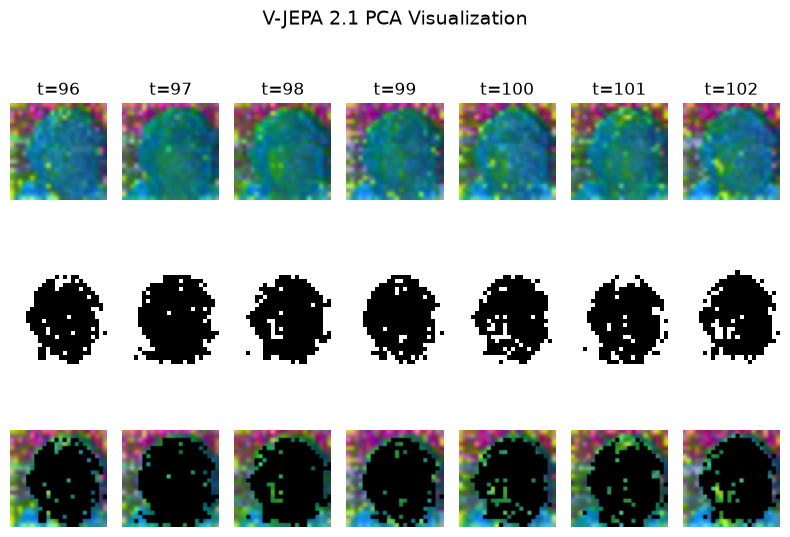

In [15]:
frames_to_show = [96, 97, 98, 99, 100, 101, 102]
fig, axes = plt.subplots(3, len(frames_to_show), figsize=(8, 6))
row_labels = ["All tokens PCA", "FG mask (PC1)", "FG-only PCA"]

for i, t in enumerate(frames_to_show):
    axes[0, i].imshow(results_full[t])
    axes[0, i].set_title(f"t={t}")

    axes[1, i].imshow(fg_mask[t], cmap='gray', vmin=0, vmax=1)

    axes[2, i].imshow(results_masked[t])

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=10)

for ax in axes.flat:
    ax.axis('off')

plt.suptitle("V-JEPA 2.1 PCA Visualization", fontsize=14)
plt.tight_layout()
plt.savefig("vjepa_pca_fg.png", dpi=150, bbox_inches='tight')
plt.show()

In [14]:
mediapy.show_video(results_full, fps=3)